In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install openai-whisper transformers datasets jiwer librosa accelerate -q
print('Libraries installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.8 MB/s eta 0:00:00
Libraries installed ✅


In [3]:
import os, tarfile

files = os.listdir('/content/drive/MyDrive/az-stt-intern/')
tar_filename = [f for f in files if f.endswith('.tar.gz')][0]
tar_path = f'/content/drive/MyDrive/az-stt-intern/{tar_filename}'
print(f'Found: {tar_filename}')

extract_path = '/content/cv-az'
os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(extract_path)

print('Extracted')

Found: 1774118365245-cv-corpus-25.0-2026-03-09-az.tar.gz


/tmp/ipykernel_4997/1363971971.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extracted


In [4]:
import pandas as pd

base_path = '/content/cv-az/cv-corpus-25.0-2026-03-09/az'
df_train = pd.read_csv(f'{base_path}/train.tsv', sep='\t')
print(f'Total train samples: {len(df_train)}')

df_train = df_train.head(180)
print(f'Using {len(df_train)} samples')

Total train samples: 215
Using 180 samples


In [5]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_train, test_size=30, random_state=42)
print(f'Train: {len(train_df)} samples')
print(f'Validation: {len(val_df)} samples')

Train: 150 samples
Validation: 30 samples


In [6]:
from transformers import WhisperProcessor

processor = WhisperProcessor.from_pretrained(
    "openai/whisper-small",
    language="az",
    task="transcribe"
)
print('Processor loaded ✅')

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Processor loaded ✅


In [8]:
import librosa
import torch

clips_path = f'{base_path}/clips'

def preprocess_df(df):
    input_features = []
    labels = []

    for i, row in df.iterrows():
        audio_path = f'{clips_path}/{row["path"]}'
        try:
            audio, sr = librosa.load(audio_path, sr=16000)
            features = processor(audio, sampling_rate=16000, return_tensors='pt').input_features[0]
            label = processor.tokenizer(row['sentence']).input_ids
            input_features.append(features)
            labels.append(label)
        except Exception as e:
            print(f'Skipping {row["path"]}: {e}')

    return input_features, labels

print('Preprocessing training data...')
train_features, train_labels = preprocess_df(train_df)
print(f'Done: {len(train_features)} train samples')

print('Preprocessing validation data...')
val_features, val_labels = preprocess_df(val_df)
print(f'Done: {len(val_features)} val samples')

Preprocessing training data...
Done: 150 train samples
Preprocessing validation data...
Done: 30 val samples


In [9]:
from torch.utils.data import Dataset

class SpeechDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return {
            'input_features': self.features[idx],
            'labels': torch.tensor(self.labels[idx])
        }

train_dataset = SpeechDataset(train_features, train_labels)
val_dataset = SpeechDataset(val_features, val_labels)
print(f'Train dataset: {len(train_dataset)} samples')
print(f'Val dataset: {len(val_dataset)} samples')

Train dataset: 150 samples
Val dataset: 30 samples


In [10]:
from dataclasses import dataclass
from typing import Any, List

@dataclass
class DataCollator:
    processor: Any

    def __call__(self, features):
        input_features = [{'input_features': f['input_features']} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors='pt')

        label_features = [{'input_ids': f['labels'].tolist()} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors='pt')

        labels = labels_batch['input_ids'].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        batch['labels'] = labels
        return batch

data_collator = DataCollator(processor=processor)
print('Data collator ready')

Data collator ready


In [16]:
from transformers import WhisperForConditionalGeneration

model = WhisperForConditionalGeneration.from_pretrained('openai/whisper-small')
model.generation_config.language = "az"
model.generation_config.task = "transcribe"
model.generation_config.forced_decoder_ids = None
print('Model loaded ✅')

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Model loaded ✅


In [12]:
import jiwer

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = jiwer.wer(label_str, pred_str)
    return {'wer': wer}

print('Metric ready')

Metric ready


In [13]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir='/content/drive/MyDrive/az-stt-intern/checkpoints',
    num_train_epochs=8,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    warmup_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='wer',
    greater_is_better=False,
    predict_with_generate=True,
    generation_max_length=225,
    logging_steps=5,
    report_to='none',
    fp16=True,
)
print('Training arguments ready')

Training arguments ready


In [18]:
from transformers import Seq2SeqTrainer, EarlyStoppingCallback

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print('Starting training...')
trainer.train()
print('Training complete ✅')

Starting training...


Epoch,Training Loss,Validation Loss,Wer
1,0.181216,0.728988,0.557789
2,0.041898,0.714190,0.542714
3,0.013591,0.729564,0.552764
4,0.006558,0.743156,0.527638
5,0.003551,0.744531,0.527638
6,0.002913,0.756246,0.512563
7,0.002168,0.756976,0.532663
8,0.002087,0.756813,0.522613


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


Training complete ✅


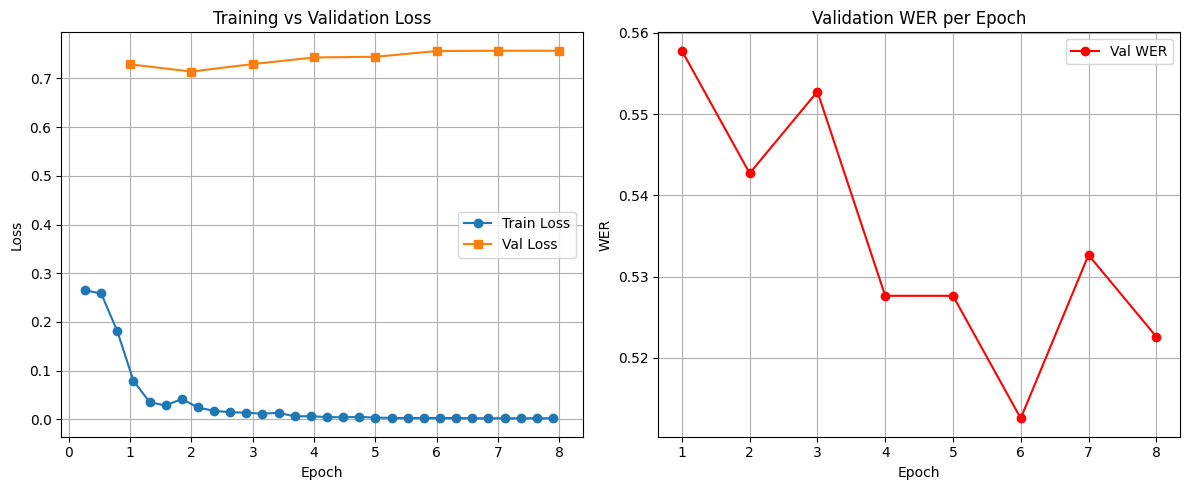

Training curves saved


In [19]:
import matplotlib.pyplot as plt
import os

save_dir = '/content/drive/MyDrive/az-stt-intern/results'

log_history = trainer.state.log_history

train_loss = [(x['epoch'], x['loss']) for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_loss  = [(x['epoch'], x['eval_loss']) for x in log_history if 'eval_loss' in x]
eval_wer   = [(x['epoch'], x['eval_wer'])  for x in log_history if 'eval_wer' in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot([x[0] for x in train_loss], [x[1] for x in train_loss], label='Train Loss', marker='o')
ax1.plot([x[0] for x in eval_loss],  [x[1] for x in eval_loss],  label='Val Loss',   marker='s')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot([x[0] for x in eval_wer], [x[1] for x in eval_wer], label='Val WER', color='red', marker='o')
ax2.set_title('Validation WER per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('WER')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/training_curves.png', dpi=150)
plt.show()
print('Training curves saved')

In [20]:
import whisper as whisper_lib
import jiwer
import pandas as pd

# Load baseline Whisper
baseline_model = whisper_lib.load_model('small')
print('Baseline model loaded ✅')

# Load test data
base_path = '/content/cv-az/cv-corpus-25.0-2026-03-09/az'
clips_path = f'{base_path}/clips'
df_test = pd.read_csv(f'{base_path}/test.tsv', sep='\t')
df_test = df_test.head(20)
print(f'Test samples: {len(df_test)}')

baseline_preds = []
finetuned_preds = []
refs = []

for i, row in df_test.iterrows():
    audio_path = f'{clips_path}/{row["path"]}'
    ref = row['sentence']
    refs.append(ref)

    # Baseline
    audio, sr = librosa.load(audio_path, sr=16000)
    base_result = baseline_model.transcribe(audio, language='az', fp16=False)
    baseline_preds.append(base_result['text'].strip())

    # Fine-tuned
    inputs = processor(audio, sampling_rate=16000, return_tensors='pt').input_features.to('cuda')
    with torch.no_grad():
        pred_ids = model.generate(inputs)
    ft_text = processor.tokenizer.decode(pred_ids[0], skip_special_tokens=True)
    finetuned_preds.append(ft_text.strip())

    print(f'[{i+1}/20] done')

print('Inference done')

100%|███████████████████████████████████████| 461M/461M [00:06<00:00, 70.5MiB/s]


Baseline model loaded ✅
Test samples: 20
[1/20] done
[2/20] done
[3/20] done
[4/20] done
[5/20] done
[6/20] done
[7/20] done
[8/20] done
[9/20] done
[10/20] done
[11/20] done
[12/20] done
[13/20] done
[14/20] done
[15/20] done
[16/20] done
[17/20] done
[18/20] done
[19/20] done
[20/20] done
Inference done


In [21]:
base_wers = [jiwer.wer(r, p) for r, p in zip(refs, baseline_preds)]
ft_wers   = [jiwer.wer(r, p) for r, p in zip(refs, finetuned_preds)]

comparison_df = pd.DataFrame({
    'reference':      refs,
    'baseline_pred':  baseline_preds,
    'finetuned_pred': finetuned_preds,
    'baseline_wer':   base_wers,
    'finetuned_wer':  ft_wers
})

avg_base_wer = sum(base_wers) / len(base_wers)
avg_ft_wer   = sum(ft_wers) / len(ft_wers)

print(f'Average Baseline WER:   {avg_base_wer:.2%}')
print(f'Average Fine-tuned WER: {avg_ft_wer:.2%}')

comparison_df.to_csv(f'{save_dir}/comparison_results.csv', index=False)
print('Comparison saved')

Average Baseline WER:   76.90%
Average Fine-tuned WER: 55.00%
Comparison saved
